# Telco Customer Churn — Classification Lab

## Objective

#### Predict whether a customer will churn.

## Goal
#### Build a simple classification model with:
•⁠  ⁠A meaningful baseline
•⁠  ⁠Proper train/test separation
•⁠  ⁠Cross-validation
•⁠  ⁠Leakage-free preprocessing
•⁠  ⁠Valid final evaluation

## Problem Definition


#### We have a dataset of customers from a telecom company containing subscription-related information and a label indicating whether each customer churned. We need to build a binary classification model that predicts whether a new customer will churn or not.

## Data Understanding

The dataset contains customer information from a telecom company. It has 7,043 rows and 21 columns, including the target variable "Churn".

#### The dataset contains information about:
•⁠  ⁠Customer demographics such as gender, senior citizen status, partner, and dependents.  
•⁠  ⁠Customer tenure with the company.  
•⁠  ⁠Telecom services subscribed to by each customer.  
•⁠  ⁠Contract and payment information.  
•⁠  ⁠Monthly and total charges.  
•⁠  ⁠The "Churn" column indicates whether the customer left the company.  

The target variable is categorical with two classes: Yes and No, making this a binary classification problem.

The dataset contains both numerical and categorical features, so preprocessing will be required before training most ML models.

In [70]:
import pandas as pd
import numpy as np

In [71]:
df = pd.read_csv("./dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [72]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
df = df.drop("customerID", axis=1)

In [74]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [76]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [77]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [78]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Exploratory Data Analysis
Initial exploration was performed to understand the distributions of important numerical variables and the target variable.
Histograms were used to inspect variables such as:
tenure
MonthlyCharges
The target distribution was also examined to understand the balance between customers who churned and those who did not.
Box plots and categorical comparisons were used to get an initial understanding of how customer characteristics relate to churn.
The purpose of this stage was to understand the dataset and identify potential data-quality issues before modeling.

<Axes: title={'center': 'tenure'}, ylabel='Frequency'>

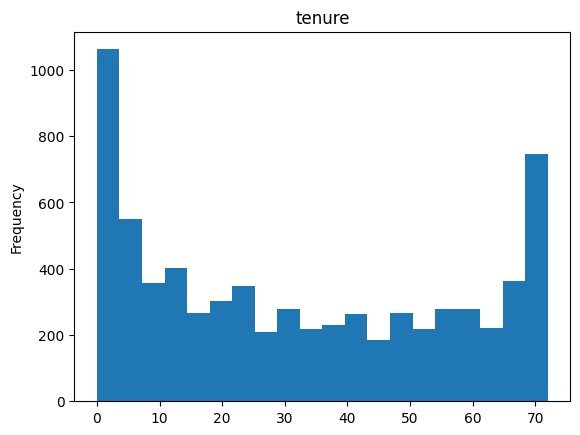

In [79]:
df["tenure"].plot(kind='hist', bins=20, title="tenure")

<Axes: title={'center': 'MonthlyCharges'}, ylabel='Frequency'>

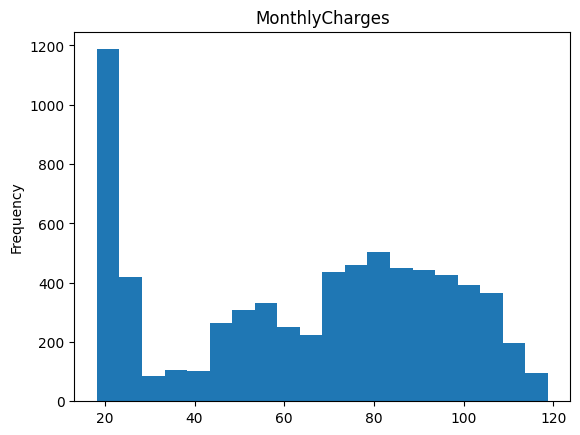

In [80]:
df["MonthlyCharges"].plot(kind='hist', bins=20, title="MonthlyCharges")

### Data Cleaning
During the initial inspection, TotalCharges was found to have an object data type even though it represents a numerical quantity.
Investigation showed that some values contained blank spaces.
These records corresponded to customers with zero tenure, meaning their total charges should logically be zero.
The column was therefore converted to a numeric type and the resulting missing values were replaced with 0.

In [81]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [82]:
df[df["TotalCharges"].str.strip() == ""]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [83]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)
df["TotalCharges"].isna().sum()

np.int64(11)

In [84]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isna().sum()

np.int64(0)

### Feature and Target Separation
The target variable was separated from the input features.
The target was kept as Yes and No rather than manually converting it to 0 and 1, since scikit-learn classifiers can work directly with categorical target labels and keeping the labels makes the results easier to interpret.

In [118]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

### Train/Test Split
The dataset was divided into training and testing sets using an 80/20 split.
Stratification was used to preserve approximately the same proportion of churned and non-churned customers in both datasets.

The test set was kept separate and was not used during model selection or cross-validation.
This allows the final model to be evaluated on genuinely unseen data.

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Baseline
A DummyClassifier using the most_frequent strategy was used as the baseline.
The baseline always predicts the majority class and does not actually learn relationships from the features.
The purpose of the baseline is to establish a minimum reference point against which the machine learning models can be compared.
The baseline produced reasonable accuracy because the dataset contains more non-churned customers, but its precision, recall, and F1 score for the churn class were zero because it did not predict any customers as churners.
This demonstrates why accuracy alone is not sufficient for evaluating this problem.

In [87]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred, pos_label="Yes"))
print("Recall:", recall_score(y_test, baseline_pred, pos_label="Yes"))
print("F1:", f1_score(y_test, baseline_pred, pos_label="Yes"))

Accuracy: 0.7345635202271115
Precision: 0.0
Recall: 0.0
F1: 0.0


/Users/mohitdevra/Desktop/ML_customer_churn_rate/.env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Feature Type Identification
The features were divided into numerical and categorical groups.  
The numerical features were:  
tenure  
MonthlyCharges  
TotalCharges  

SeniorCitizen was treated as categorical even though it is stored as an integer because its values represent categories (0 and 1) rather than a continuous numerical quantity.
The remaining features were treated as categorical.
This demonstrates that feature type should be determined using both the data type and the meaning of the feature.

In [89]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X_train.columns
    if col not in numerical_features
]

### Preprocessing
Different preprocessing techniques were required for numerical and categorical features.  
Numerical features were standardized using StandardScaler.  
Categorical features were converted into numerical representations using OneHotEncoder.  
A ColumnTransformer was used to apply the appropriate transformation to each feature group.  
The preprocessing was placed inside a scikit-learn Pipeline.  

This is important because the preprocessing transformations must be learned only from the training data during cross-validation. Performing preprocessing on the complete dataset before splitting could introduce data leakage.

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### Logistic Regression
Logistic Regression was selected as the first machine learning model because it is a simple and interpretable classification algorithm and provides a strong starting point for binary classification.  
It also works well with the mixture of numerical and one-hot encoded categorical features in this dataset.  
The model was combined with the preprocessing pipeline so that preprocessing and model training were treated as one complete workflow.

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

### Random Forest
Random Forest was selected as a second model because it represents a different model family from Logistic Regression.  
Logistic Regression is a linear model, while Random Forest can capture nonlinear relationships and interactions between features.  
The purpose was not to test every available classification algorithm, but to compare two reasonable approaches and determine which performs better on this particular dataset.

In [109]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

### Cross-Validation
Five-fold Stratified Cross-Validation was used to evaluate the models on the training data.
Stratification was used to preserve the class distribution in each fold.  
The evaluated metrics were:  
Accuracy  
Precision  
Recall  
F1 score  
ROC-AUC  

Cross-validation provides a more reliable estimate of model performance than relying on a single train/validation split.
The test set remained untouched during this process.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label="Yes"
    ),
    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),
    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    ),
    "roc_auc": "roc_auc"
}

In [127]:
logistic_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
print("Logistic regression results")
print()
print("accuracy: ",logistic_results["test_accuracy"].mean())
print("precision: ", logistic_results["test_precision"].mean())
print("reacll: ", logistic_results["test_recall"].mean())
print("f1 score: ", logistic_results["test_f1"].mean())
print("roc_auc", logistic_results["test_roc_auc"].mean())

Logistic regression results

accuracy:  0.8019183578906889
precision:  0.6520936350656179
reacll:  0.5438127090301004
f1 score:  0.5924124081667455
roc_auc 0.846149025453707


In [124]:
rf_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
print("Random forest results")
print()
print("accuracy: ",rf_results["test_accuracy"].mean())
print("precision: ", rf_results["test_precision"].mean())
print("reacll: ", rf_results["test_recall"].mean())
print("f1 score: ", rf_results["test_f1"].mean())
print("roc_auc", rf_results["test_roc_auc"].mean())

Random forest results

accuracy:  0.7864781930997744
precision:  0.628186996415051
reacll:  0.4816053511705686
f1 score:  0.54484768932455
roc_auc 0.8196478833629305


### Model Comparison
The cross-validation results were:  

Logistic Regression,
Random Forest  
Accuracy  
0.802,
0.786  

Precision  
0.652,
0.628  

Recall  
0.544,
0.482  

F1  
0.592,
0.545  

ROC-AUC  
0.846,
0.820  

Logistic Regression performed better than Random Forest across all evaluated metrics.  
Therefore, Logistic Regression was selected as the final candidate model for evaluation on the unseen test set.  
The model selection was based on cross-validation results rather than test-set performance.

In [128]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

### Final Test Evaluation
After selecting Logistic Regression using cross-validation, the model was fitted on the complete training dataset.  
The model was then evaluated once on the previously untouched test set.  
The final test results were:  

Class | Precision | Recall | F1 | Support |
:--- | :---: | :---: | :---: | ---: |
No | 0.85 | 0.89 | 0.87 | 1035 |
Yes | 0.66 | 0.56 | 0.60 | 374 |

Overall accuracy was 0.81.  

The model performs considerably better at identifying customers who do not churn than customers who do churn.

In [113]:
final_pred = logistic_model.predict(X_test)

In [114]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_pred
))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Confusion Matrix and Error Analysis
The confusion matrix separates predictions into four categories:  

True Negative (TN): Correctly predicted non-churn  
False Positive (FP): Predicted churn but the customer did not churn  
False Negative (FN): Predicted non-churn but the customer actually churned  
True Positive (TP): Correctly predicted churn  

For this business problem, false negatives are particularly important because they represent customers who actually churned but were not identified by the model.  

The model's recall for the "Yes" class was approximately 56%, meaning it identified about 56% of the customers who actually churned.  
Therefore, a significant number of churners are still being missed.

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred, labels=["No", "Yes"])
print(cm)

[[926 109]
 [165 209]]


### Business Interpretation
The current model achieves approximately 81% overall accuracy, but accuracy is not the main metric for this problem.  
The business objective is to identify customers who are likely to churn.  
A false positive means the company incorrectly identifies a customer as likely to churn. This may result in unnecessary retention efforts, but it is considered more acceptable in this scenario.  
A false negative means the company fails to identify a customer who actually churns. This is considered more costly.  
Therefore, recall for the "Yes" class is an important metric, and improving recall may be worth accepting some reduction in precision.

### Conclusion
The experiment established a baseline and compared two classification models using stratified cross-validation.  

Logistic Regression performed better than Random Forest across the evaluated metrics and was therefore selected for final evaluation.  

The final model achieved 81% accuracy and 56% recall for the churn class on the unseen test set.  

Although the model provides useful predictive performance, it still misses a substantial proportion of actual churners.  

The next potential improvement is to adjust the classification threshold to increase recall while monitoring the resulting reduction in precision.